In [1]:
import pandas as pd
import random
import matplotlib.pyplot as plt

In [8]:
def load_data(file_path):
    df = pd.read_excel(file_path)

    # Drop rows with missing critical values
    df = df.dropna(subset=['Feedstock Price', 'Conversion Price', 'Transport Price', 'Grammage'])
    df = df.drop_duplicates()

    # Keep only active materials
    if 'Material Status' in df.columns:
        df = df[df['Material Status'] == 'active']

    # Calculate historical totals
    df['Calculated Price'] = df['Feedstock Price'] + df['Conversion Price'] + df['Transport Price']
    df['Efficiency Price'] = df['Calculated Price'] / df['Grammage']

    return df

In [9]:
def random_search_material(df, material_name, n_iter=1000):
    # Filter material safely (ignoring case and extra spaces to prevent "empty sequence" errors)
    data = df[
        df['Material Description'].astype(str).str.strip().str.lower() == str(material_name).strip().lower()].copy()

    # Safety check: if no data is found for this material, exit early
    if data.empty:
        return None, None, None

    # Extract available suppliers and plants specifically for this material
    suppliers = data['Supplier'].dropna().unique()
    plants = data['Plant'].dropna().unique()

    # Safety check: ensure we have at least one supplier and one plant to choose from
    if len(suppliers) == 0 or len(plants) == 0:
        return None, None, None

    results = []

    # Run the Monte Carlo / Random Search simulation
    for _ in range(n_iter):
        # Randomly select one supplier and one plant combination
        supplier = random.choice(suppliers)
        plant = random.choice(plants)

        # Filter the dataset for the chosen supplier and plant
        supplier_data = data[data['Supplier'] == supplier]
        plant_data = data[data['Plant'] == plant]

        # If either doesn't exist for this material, skip to next iteration
        if supplier_data.empty or plant_data.empty:
            continue

        # Randomly select a specific historical row for the supplier (dictates Feedstock & Conversion)
        row_supplier = supplier_data.sample(1).iloc[0]

        # Randomly select a specific historical row for the plant (dictates Transport)
        row_transport = plant_data.sample(1).iloc[0]

        # Extract the component prices to build the synthetic price
        feedstock = row_supplier['Feedstock Price']
        conversion = row_supplier['Conversion Price']
        transport = row_transport['Transport Price']
        grammage = row_supplier['Grammage']

        # Calculate the new synthetic total price and efficiency
        total_price = feedstock + conversion + transport
        efficiency = total_price / grammage

        # Save the result of this synthetic combination
        results.append({
            'Material Description': material_name,
            'Supplier': supplier,
            'Plant': plant,
            'Feedstock Price': feedstock,
            'Conversion Price': conversion,
            'Transport Price': transport,
            'Total Synthetic Price': total_price,
            'Synthetic Efficiency': efficiency
        })

    # If no valid combinations were successfully formed, exit
    if len(results) == 0:
        return None, None, None

    results_df = pd.DataFrame(results)

    # Identify the best overall theoretical price and efficiency from the random samples
    best_total = results_df.loc[results_df['Total Synthetic Price'].idxmin()]
    best_eff = results_df.loc[results_df['Synthetic Efficiency'].idxmin()]

    return results_df, best_total, best_eff

In [10]:
def plot_random_search_distribution(results_df, material_name):
    if results_df is None or results_df.empty:
        print(f"No data to plot for {material_name}.")
        return

    plt.style.use('dark_background')
    plt.figure(figsize=(14, 7))

    plt.hist(results_df['Total Synthetic Price'], bins=50, color='cyan', edgecolor='black', alpha=0.7,
             label='Simulated Combinations')

    best_price = results_df['Total Synthetic Price'].min()
    avg_price = results_df['Total Synthetic Price'].mean()
    worst_price = results_df['Total Synthetic Price'].max()

    plt.axvline(best_price, color='lime', linestyle='-', linewidth=3, label=f'Best Found: {best_price:.2f}')
    plt.axvline(avg_price, color='yellow', linestyle='--', linewidth=2, label=f'Average: {avg_price:.2f}')
    plt.axvline(worst_price, color='crimson', linestyle=':', linewidth=2, label=f'Worst: {worst_price:.2f}')

    plt.title(f'{material_name}\nDistribution of {len(results_df)} Synthetic Combinations',
              fontsize=16, fontweight='bold', color='white')
    plt.xlabel('Total Synthetic Price', fontsize=12, color='lightgray')
    plt.ylabel('Frequency', fontsize=12, color='lightgray')

    plt.legend(facecolor='black', edgecolor='white', fontsize=12)
    plt.grid(True, linestyle=':', alpha=0.4)
    plt.tight_layout()
    plt.show()


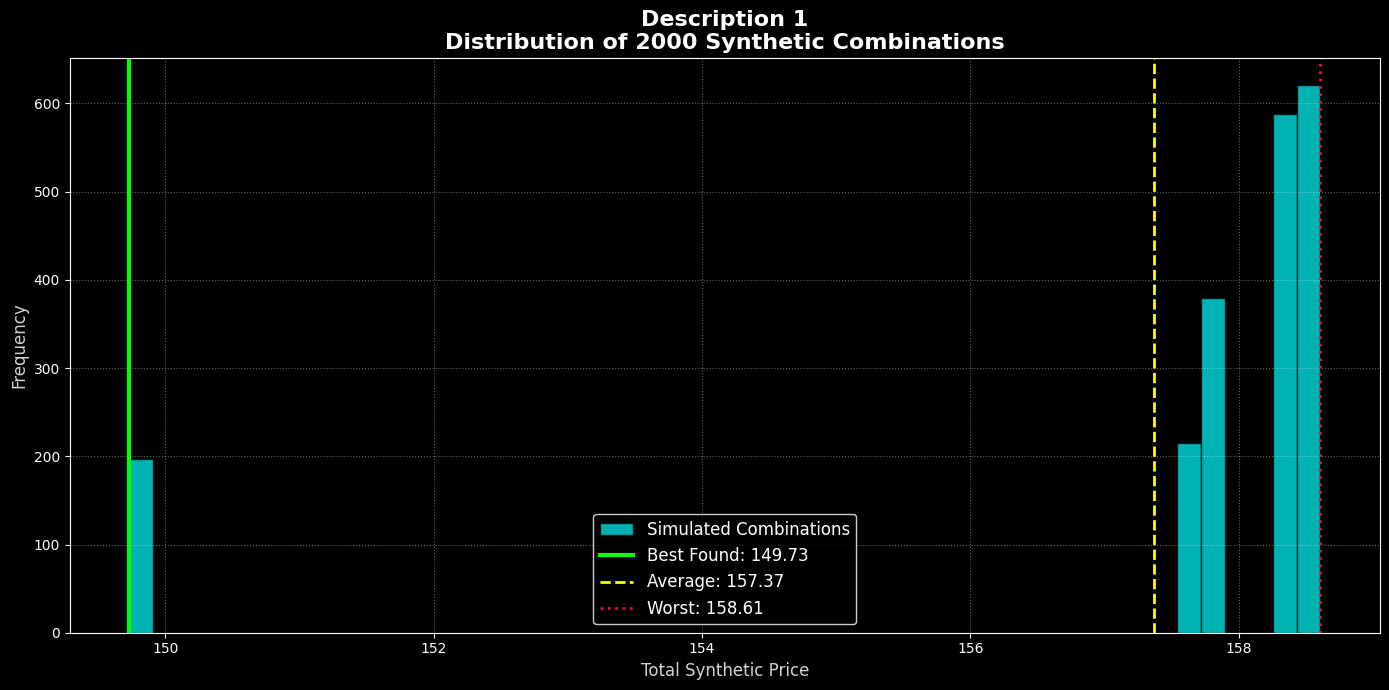

Graficul a fost afisat.


In [15]:
file_path = "../Project 2 Data.xlsx"


df = load_data(file_path)

test_material = "Description 1"  # Modifica cu numele materialului tau

results_df, best_total, best_eff = random_search_material(df, test_material, n_iter=2000)

if results_df is not None:
    plot_random_search_distribution(results_df, test_material)
    print("Graficul a fost afisat.")
else:
    print(f"Nu s-au gasit combinatii pentru {test_material}.")